In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [4]:
df['X'] = df['3.159499363321345566e-02']
df['Y'] = df['9.869877579082642072e-01']
df['class'] = df['0.000000000000000000e+00']

df.drop(['3.159499363321345566e-02', '9.869877579082642072e-01', '0.000000000000000000e+00'], axis=1, inplace=True)

In [5]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


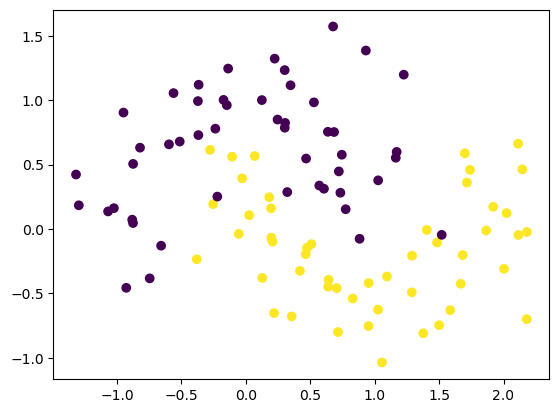

In [6]:
plt.scatter(x = df['X'], y = df['Y'], c=df['class'])

In [7]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [9]:
model = Sequential()

model.add(Dense(10, activation='tanh', input_dim=2))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.get_weights()

[array([[ 0.01347959, -0.18887198, -0.11982852,  0.32208735,  0.5764714 ,
          0.02509475, -0.67244804,  0.54581875,  0.23640555, -0.3479546 ],
        [-0.6958345 , -0.62567836,  0.02833515, -0.42021722, -0.46965346,
         -0.21248737,  0.19160295, -0.04640555,  0.43603307,  0.5814758 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.09379309,  0.5339123 ,  0.32952255,  0.24240923,  0.04155153,
         -0.3992009 ,  0.41934985, -0.24093086,  0.08995056, -0.22125775],
        [-0.43114787,  0.12952518, -0.21606821,  0.3780614 , -0.22266692,
          0.2582137 , -0.18238154, -0.44605127, -0.15022182,  0.368446  ],
        [ 0.4113254 , -0.076334  , -0.31980345,  0.43386394, -0.38088864,
         -0.07627508, -0.01973683, -0.41759032,  0.40827864,  0.52675915],
        [-0.01384604, -0.4258237 ,  0.3579499 , -0.02361041, -0.43292922,
          0.42511344, -0.36023784, -0.23137408, -0.23007303,  0.42051154],
        [ 0.50455

In [11]:
initial_weights = model.get_weights()

In [12]:
initial_weights[0] = np.random.randn(2, 10) * np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10, 10) * np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10, 10) * np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10, 10) * np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10, 1) * np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [13]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[-0.4416533 , -0.0518554 ,  0.44468164,  0.10002838, -1.7755631 ,
          0.6450245 ,  0.41295254, -0.2840894 , -0.7754779 , -0.2734801 ],
        [-0.00676564,  1.2182662 ,  0.8970398 ,  0.9980569 ,  0.7410524 ,
          0.6447444 ,  0.47531334,  0.01924453, -0.20859405, -0.00627806]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 8.76618773e-02,  5.81581295e-01, -8.07148442e-02,
          6.41278267e-01, -1.45609722e-01, -2.90164083e-01,
          1.08671971e-01, -3.39303523e-01, -3.18092108e-01,
         -4.40292746e-01],
        [-2.03621745e-01,  5.34045875e-01, -8.42265338e-02,
         -3.54315847e-01,  3.09362352e-01, -2.79778391e-01,
         -2.71564964e-02, -9.71181095e-02, -1.58742383e-01,
         -9.23659876e-02],
        [ 2.53949076e-01, -3.54175419e-01,  5.55350900e-01,
          2.51006842e-01, -5.32941282e-01,  1.38993755e-01,
         -4.85323630e-02, -5.02110243e-01,  8.76931995e-02,
         -2.7753093

In [15]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
history = model.fit(X,y, epochs=50, validation_split=0.2)

Epoch 1/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9688 - loss: 0.0624

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9620 - loss: 0.0579 - val_accuracy: 1.0000 - val_loss: 0.0388
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9494 - loss: 0.0585 - val_accuracy: 1.0000 - val_loss: 0.0379
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9620 - loss: 0.0577 - val_accuracy: 1.0000 - val_loss: 0.0319
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9620 - loss: 0.0564 - val_accuracy: 1.0000 - val_loss: 0.0252
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9747 - loss: 0.0567 - val_accuracy: 1.0000 - val_loss: 0.0213
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9747 - loss: 0.0577 - val_accuracy: 1.0000 - val_loss: 0.0192
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9747 - loss: 0.0577 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9747 - loss: 0.0574 - val_accuracy: 1.0000 - val_loss: 0.0164
Epoch 9/50


In [33]:
model.get_weights()

[array([[-0.52988154, -0.5450389 ,  0.68170536,  0.07605381, -2.1679363 ,
          0.95960736,  0.6672602 , -0.38535702, -0.6352902 , -0.11560302],
        [ 0.119104  ,  0.87249696,  1.6042043 ,  1.522713  ,  0.45230082,
          0.9370842 ,  0.15631248,  0.20292112,  0.00917513, -0.4122114 ]],
       dtype=float32),
 array([-0.0553738 ,  0.00148331, -0.3820395 , -0.38545525,  0.5904813 ,
        -0.44547066,  0.16812585,  0.06100731,  0.16640043,  0.22936724],
       dtype=float32),
 array([[ 0.2876054 ,  0.9586027 ,  0.09661294,  0.4068931 ,  0.08664493,
         -0.38092342,  0.01697766, -0.27906594, -0.34193638, -0.6839518 ],
        [-0.12740484,  0.45129895,  0.05161012, -0.6609236 ,  0.60635173,
         -0.40795308, -0.00519902, -0.17375095,  0.03429041, -0.27437988],
        [ 0.0882999 , -0.8986599 ,  0.72196966, -0.01144976, -0.43153152,
         -0.01964822,  0.36349708, -0.6675876 ,  0.36904132, -0.38580337],
        [-0.02399366, -0.30496415,  0.04920043, -0.36183858, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


<Axes: >

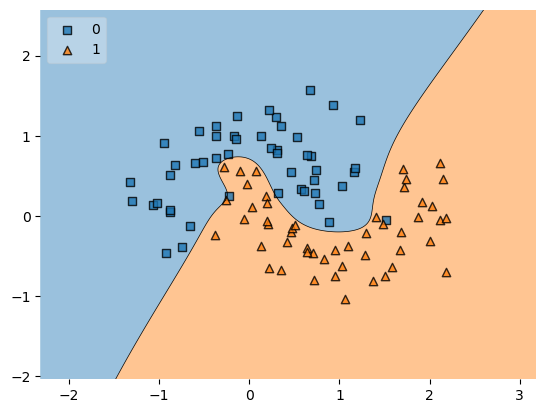

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype(int), clf=model, legend=2)